### Testing cubes/construct package

This is a notebook to perform a test to determine if the construct package can produce a reliable idf file

In [1]:
from cubes.construct import building
from cubes.construct import sample
from cubes.construct.extractor import Extractor
from cubes.construct import constants
from geomeppy import IDF
import numpy as np
import pandas as pd
import math

import os
from pathlib import Path

In [2]:
def sample_idf():
    geometry_data, systems_data = sample.sample_database(
        constants.filtered_geometry_data, constants.clean_system_data
    )
    building_config = Extractor(geometry_data, systems_data)
    build = building.Building(building_config)
    build.build()
    idf = build.get_idf()

    return idf

def test_minimal_idf():
    geometry_data, systems_data = sample.sample_database(
        constants.filtered_geometry_data, constants.clean_system_data
    )
    building_config = Extractor(geometry_data, systems_data)
    build = building.Building(building_config)
    build.build()
    idf = build.get_idf()
    return idf

def test_walls():
    geometry_data, systems_data = sample.sample_database(
        constants.filtered_geometry_data, constants.clean_system_data
    )
    building_config = Extractor(geometry_data, systems_data)
    walls = building_config.calc_wall_length()
    
    return walls, geometry_data

def test_idf():

    idf1 = sample_idf()
    cwd_path = os.getcwd()
    env_data_path = os.path.join(cwd_path, "input_case_1")
    output_directory_path = os.path.join(env_data_path, "output")

    Path(env_data_path).mkdir(parents=True, exist_ok=True)
    Path(output_directory_path).mkdir(parents=True, exist_ok=True)

    idf1.save()
    idf1.run(
        expandobjects=True,
        weather=(
            "/workspaces/CUBES/src/cubes/data/weather/cambridge_lat=52.25_lng=0.25_period=2021.epw"
        ),
        output_directory=output_directory_path,
    )

6    HVACTemplate:Plant:Boiler CondensingHotWaterBo...
dtype: object NaturalGas


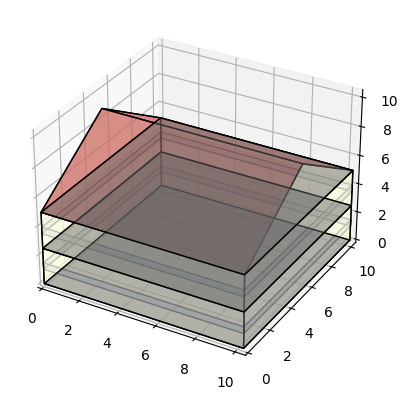

In [4]:
idf = test_minimal_idf()
idf.view_model()

In [ ]:
idf.idfobjects["SIZ"]

In [8]:
test_idf()

4    HVACTemplate:Plant:Boiler HotWaterBoiler
dtype: object NaturalGas

/usr/local/EnergyPlus-9-5-0/energyplus --weather /workspaces/CUBES/src/cubes/data/weather/cambridge_lat=52.25_lng=0.25_period=2021.epw --output-directory /workspaces/CUBES/exp/jack/construct-tests/input_case_1/output --idd /usr/local/EnergyPlus-9-5-0/Energy+.idd --expandobjects /usr/local/EnergyPlus-9-5-0/ExampleFiles/Minimal_ae47fe.idf

ExpandObjects Started.
 Begin reading Energy+.idd file.
 Done reading Energy+.idd file.
ExpandObjects Finished with Error(s). Time:     0.057
EnergyPlus Starting
EnergyPlus, Version 9.5.0-de239b2e5f, YMD=2023.01.27 16:54
**FATAL:Errors occurred on processing input file. Preceding condition(s) cause termination.
EnergyPlus Run Time=00hr 00min  0.48sec


Program terminated: EnergyPlus Terminated--Error(s) Detected.


EnergyPlusRunError: 

Contents of EnergyPlus error file at /workspaces/CUBES/exp/jack/construct-tests/input_case_1/output/eplusout.err
Program Version,EnergyPlus, Version 9.5.0-de239b2e5f, YMD=2023.01.27 16:54,
   ** Severe  ** Duplicate name found for object of type "SizingPeriod:WeatherFileDays" named "Winter Design Day". Overwriting existing object.
   ** Severe  ** Duplicate name found for object of type "SizingPeriod:WeatherFileDays" named "Summer Design Day". Overwriting existing object.
   ** Severe  ** Duplicate name found for object of type "Schedule:Compact" named "People-Schedule". Overwriting existing object.
   ** Severe  ** Duplicate name found for object of type "Schedule:Compact" named "Always-Schedule". Overwriting existing object.
   ** Severe  ** Duplicate name found for object of type "Schedule:Compact" named "Activity-Schedule". Overwriting existing object.
   ** Severe  ** Duplicate name found for object of type "Schedule:Compact" named "Heating-Setpoint-Block 

In [ ]:
rc = [[[0, 4.459849916062032, 6.348805984280581], [0, 0, 5.0], [8.919699832124063, 0, 5.0], [8.919699832124063, 4.459849916062032, 6.348805984280581]], [[8.919699832124063, 4.459849916062032, 6.348805984280581], [8.919699832124063, 8.919699832124063, 5.0], [0, 8.919699832124063, 5.0], [0, 4.459849916062032, 6.348805984280581]]]
[[[0, 4.459849916062032, 6.348805984280581], [0, 0, 5.0], [8.919699832124063, 0, 5.0], [8.919699832124063, 4.459849916062032, 6.348805984280581]], [[8.919699832124063, 4.459849916062032, 6.348805984280581], [8.919699832124063, 8.919699832124063, 5.0], [0, 8.919699832124063, 5.0], [0, 4.459849916062032, 6.348805984280581]]]
[[[0, 4.459849916062032, 6.348805984280581], [0, 0, 5.0], [8.919699832124063, 0, 5.0], [8.919699832124063, 4.459849916062032, 6.348805984280581]], [[8.919699832124063, 4.459849916062032, 6.348805984280581], [8.919699832124063, 8.919699832124063, 5.0], [0, 8.919699832124063, 5.0], [0, 4.459849916062032, 6.348805984280581]]]

In [ ]:
rc

In [ ]:
walls = {'Country': [], 'Code': [], 'wall_lengths': []}
for m in range(0,100):
    wall, gm = test_walls()
    walls['Country'].append(gm['REFERENCE BUILDING COUNTRY CODE'].values[0])
    walls['Code'].append(gm['REFERENCE BUILDING CODE'].values[0])
    walls['wall_lengths'].append(math.isnan(wall[0]))

df = pd.DataFrame.from_dict(walls)
df[df['wall_lengths'] == True]

In [ ]:
cwd_path = os.getcwd()
env_data_path = os.path.join(cwd_path, "input_case_1")

In [ ]:
env_data_path

In [ ]:
def clean_minimal_idf(self):
        properties_needing_cleaned = [
            "MATERIAL",
            "CONSTRUCTION",
            "BUILDINGSURFACE:DETAILED",
            "FENESTRATIONSURFACE:DETAILED",
        ]
        for prop in properties_needing_cleaned:
            self.idf.idfobjects[prop].clear()

        return self.idf